# MCMC example

This notebook will fit to differential cross section data for $\omega$ and $\phi$ photoproduction.

## 1. Load data and packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time

# Import photoproduction model
from photoproductionmodel import *

# Import photoproduction data sets
omega_photo_data = read_csv("selected_omega_dataset.csv")
phi_photo_data = read_csv("selected_phi_dataset.csv")
rho_photo_data = read_csv("ballam_data.csv")

# Import electroproduction data sets
rho_electro_data = read_csv("Joos Data Table 1.csv")


## 2. Define priors

In [4]:
# Priors on variable parameters
#  params[0] = g_pi_NN
#  params[1] = g_eta_NN
#  params[2] = Lambda_pi_NN
#  params[3] = Lambda_eta_NN
#  params[4] = Lambda_pi_gam_omega
#  params[5] = Lambda_eta_gam_omega
#  params[6] = Lambda_pi_gam_phi
#  params[7] = Lambda_eta_gam_phi
#  params[8] = b_Pom_omega_omega
#  params[9] = b_Pom_phi_phi
#  params[10] = B_omega (form factor slope)
#  params[11] = B_phi (form factor slope)
#  params[12] = alpha_Pom (Pomeron trajectory)
#  params[13] = a_Pom_omega_omega
#  params[14] = a_Pom_phi_phi 
#  params[15] = Lambda_pi_gam_rho
#  params[16] = Lambda_eta_gam_rho
#  params[17] = b_Pom_rho_rho
#  params[18] = a_Pom_rho_rho
#  params[19] = B_rho (form factor slope)
#  params[20] = a_f2_rho_rho
#  params[21] = b_f2_rho_rho
#  params[22] = alpha_R_plus (Reggeon trajectory intercept)

# Central values at 0 and errors at 1e5 (large number) do not contribute to prior
cent_values = np.array([13, 4, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0, 0, 0, 0, 0, 0, 0, 0.8, 0.8, 0, 0, 0, 0, 0, 0])
prior_errors = np.array([1, 1, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 1e5, 1e5, 1e5, 1e5, 1e5, 1e5, 1e5, 0.2, 0.2, 1e5, 1e5, 1e5, 1e5, 1e5, 1e5])

def chi_sq_priors(params):

    # Require Eq. (A8) from Ben Othman 2311.00043 
    # a_PVV > 0 and b_PVV + 2 * mV^2 * a_PVV > 0
    # for all V = omega, phi, rho
    a_Pom_omega_omega, b_Pom_omega_omega = params[13], params[8]
    a_Pom_rho_rho, b_Pom_rho_rho = params[18], params[17]
    a_Pom_phi_phi, b_Pom_phi_phi = params[14], params[9]

    # If any inequalities not satisfied, return infinity
    if (a_Pom_omega_omega < 0) or (a_Pom_rho_rho < 0) or (a_Pom_phi_phi < 0):
        return np.inf
    elif (2*m_omega**2 * a_Pom_omega_omega + a_Pom_omega_omega < 0):
        return np.inf
    elif (2*m_phi**2 * a_Pom_phi_phi + b_Pom_phi_phi < 0):
        return np.inf
    elif (2*m_rho**2 * a_Pom_rho_rho + b_Pom_rho_rho < 0):
        return np.inf

    # Else impose Gaussian prior on parameters
    else:
        return np.sum((params - cent_values)**2/prior_errors**2)



## 3. Comparison to data

The likelihood function is $P = e^{- \chi^2/2}$ where the total $\chi^2$ as a sum of six terms:

$$\chi^2 = \chi^2_{\gamma p \to \omega p} + \chi^2_{\gamma p \to \phi p} + \chi^2_{\gamma p \to \rho p} + \chi^2_{\gamma^{*} p \to \phi p} + \chi^2_{\gamma p \to {\rm all}} + \chi^2_{\rm priors}$$

- $\chi^2_{\gamma p \to \omega p}$ and $\chi^2_{\gamma p \to \phi p}$ are from exclusive differential cross section data for $\omega$ and $\phi$ photoproduction
- $\chi^2_{\gamma p \to \rho p}$ and $\chi^2_{\gamma^{*} p \to \rho p}$ are from exclusive differential cross section data for $\rho$ production with real and virtual photons, the latter from electroproduction data
- $\chi^2_{\rm priors}$ is for the priors as defined above
- $\chi^2_{\gamma p \to {\rm all}}$ is from the inclusive photon-proton scattering cross section at high energy (for all final states), given in Eq. (A9) in Ben Othman et al (2311.00043)

In [97]:
# chi^2 for omega photoproduction data for exclusive differential cross section (gamma p -> omega p)
def chi_sq_omega_data(params):
    
    W = omega_photo_data['W']
    t = omega_photo_data['t']
    obs = omega_photo_data['dsigdt (mu barn/GeV^2)']
    err = omega_photo_data['dsigdt error (mu barn/GeV^2)']

    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )
    
    model = dsig_dt_omega(W,t,params)
    
    return np.sum((model - obs)**2/err_tot**2)

# chi^2 for phi photoproduction data for exclusive differential cross section (gamma p -> phi p)
def chi_sq_phi_data(params):
    
    W = phi_photo_data['W']
    t = phi_photo_data['t']
    obs = phi_photo_data['dsigdt (mu barn/GeV^2)']
    err = phi_photo_data['dsigdt error (mu barn/GeV^2)']
    
    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )

    model = dsig_dt_phi(W,t,params)
    
    return np.sum((model - obs)**2/err_tot**2)

# chi^2 for rho photoproduction data for exclusive differential cross section (gamma p -> rho p)
def chi_sq_rho_data(params):
    
    W = rho_photo_data['W']
    t = rho_photo_data['t']
    obs = rho_photo_data['dsigdt (mu barn/GeV^2)']
    err = rho_photo_data['dsigdt error (mu barn/GeV^2)']

    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )
    
    model = dsig_dt_rho(W,t,params)
    
    return np.sum((model - obs)**2/err_tot**2)

# chi^2 for rho electroproduction data for exclusive cross section (gamma^* p -> rho p)
def chi_sq_rho_data_e(params):
    
    W = rho_electro_data['W']
    Q2 = rho_electro_data['Q2']
    s_tot = rho_electro_data['s_tot']
    obs = rho_electro_data['sig (mu barn)']
    err = rho_electro_data['sig error (mu barn)']

    # Calculate total error including a 10% systematic error
    sys_err = 0.1 * obs 
    err_tot = np.sqrt( err**2 + sys_err**2 )
    
    model = sig_virtual_rho(s_tot,W,Q2,params)
    
    return np.sum((model - obs)**2/err_tot**2)
    
# chi^2 for photon-proton inclusive cross section (gamma p -> all final states)
def chi_sq_gamma_proton(params):

    # See Eq. (A9) from Ben Othman 2311.00043 
    
    # Data from H1 expt
    obs_H1, stat_error_H1, sys_error_H1 = 165, 2, 11 # mu barn
    tot_error_H1 = np.sqrt(stat_error_H1**2 + sys_error_H1**2)

    # H1 CM energy
    E_CM = 200 # GeV
    s_tot = E_CM**2

    # Model prediction for H1 energy
    model_H1 = sig_gamma_proton_tot(s_tot,params)

    # Data from Zeus expt
    obs_Zeus, stat_error_Zeus, sys_error_Zeus = 174, 1, 13 # mu barn
    tot_error_Zeus = np.sqrt(stat_error_Zeus**2 + sys_error_Zeus**2)

    # Zeus CM energy
    E_CM = 209 # GeV
    s_tot = E_CM**2

    # Model prediction for Zeus energy
    model_Zeus = sig_gamma_proton_tot(s_tot,params)

    return (model_H1 - obs_H1)**2 / tot_error_H1**2 + (model_Zeus - obs_Zeus)**2 / tot_error_Zeus**2
    
# Total chi^2
def chi_sq_tot(params):
    return chi_sq_omega_data(params) + chi_sq_phi_data(params) + chi_sq_rho_data(params) + chi_sq_priors(params) + chi_sq_gamma_proton(params) # + chi_sq_rho_data_e(params)

# Test on default_params
chi_sq_tot(default_params), chi_sq_rho_data_e(default_params)

(np.float64(1548.8905387814857), np.float64(1885.3094522188446))

## 4. MCMC scan

Basic Metropolis algorithm

In [116]:
# MCMC scan

# First parameter point
# x0 = default_params
# x0 = np.array([14.75154191,  5.85745089,  0.91796626,  0.92594924,  0.61208057,
#         1.05707661,  0.94692618,  0.30391755,  5.14490122,  2.6755781 ,
#         8.02203246,  2.89836413,  1.08969212,  3.73158854,  0.24361417,
#         0.75290277,  0.95167284,  4.90961623,  0.26908995,  4.29757042,
#         2.52196575,  0.326985  ,  1.08609673])

chi_sq_old = chi_sq_tot(x0)

# Initialize chain
num = 30000
num_params = len(x0)
# cov = np.diag([1e-4] * num_params)

# cov = 0.3 * np.array([[ 1.57984273e-02, -1.06479809e-02, -1.16749374e-03,
#          1.75528962e-03, -1.02525052e-04,  9.49222188e-06,
#          6.54572314e-04, -1.89726308e-03, -6.56074552e-03,
#         -6.46714061e-03, -4.20393956e-03,  3.87815360e-03,
#          1.50957221e-04, -9.47935141e-03,  6.12332490e-03,
#          2.55896493e-03,  6.07408463e-03, -2.59162383e-03,
#          2.66540104e-03,  2.23133040e-03, -1.63816798e-03,
#          1.52000237e-03,  2.11207488e-04],
#        [-1.06479809e-02,  2.62358336e-02,  8.57998779e-04,
#         -1.03292969e-02,  2.79718453e-05,  1.95890395e-04,
#         -1.03041838e-02,  4.57100371e-03,  2.19018067e-02,
#          1.74352623e-02,  1.01968282e-02, -9.79751141e-03,
#         -3.99458083e-04,  5.91225871e-03, -1.54204389e-02,
#          1.94631063e-03, -3.38689841e-03,  1.19807278e-02,
#         -1.13698304e-02, -4.74279246e-03, -6.16335087e-03,
#          3.27098108e-03, -1.00201774e-04],
#        [-1.16749374e-03,  8.57998779e-04,  1.78021902e-03,
#         -6.05138780e-04, -4.60141975e-04, -2.77916036e-04,
#         -1.51851013e-03,  9.64819660e-04,  3.03095408e-03,
#          1.59410086e-03,  1.19106497e-03, -8.66454440e-04,
#         -8.07496376e-06,  2.23721614e-03, -1.54273469e-03,
#         -2.41467907e-03,  3.80504853e-04, -3.83394089e-04,
#         -1.64028397e-03, -1.70681093e-03,  4.28890304e-04,
#         -9.26885719e-05, -3.58753361e-05],
#        [ 1.75528962e-03, -1.03292969e-02, -6.05138780e-04,
#          8.36022206e-03,  2.51492061e-06,  2.37324327e-03,
#          5.52517913e-03, -1.70661463e-03, -1.28059852e-02,
#         -1.09953892e-02, -4.62590078e-03,  6.52330264e-03,
#          2.02417635e-04, -1.63314435e-03,  1.00996666e-02,
#         -9.92226846e-04,  7.32888175e-04, -5.48546497e-03,
#          7.07204295e-03,  5.09250180e-03,  6.26822638e-03,
#         -4.97359958e-03,  9.17049581e-05],
#        [-1.02525052e-04,  2.79718453e-05, -4.60141975e-04,
#          2.51492061e-06,  1.65936414e-04, -5.46801849e-04,
#          2.61980594e-04, -1.34569025e-04, -5.42593172e-04,
#         -8.46512861e-05, -5.00069652e-04,  2.55672356e-05,
#          8.38892191e-07, -6.68511435e-04,  8.32137526e-05,
#          6.59356697e-04, -4.82031326e-04,  3.52919350e-04,
#          6.86599387e-04,  3.27670034e-04, -1.77659933e-04,
#          2.65539005e-04, -3.88483112e-05],
#        [ 9.49222188e-06,  1.95890395e-04, -2.77916036e-04,
#          2.37324327e-03, -5.46801849e-04,  1.22868737e-02,
#          3.02941772e-03, -1.73734660e-03, -3.63054653e-03,
#         -4.17928190e-03,  5.60006632e-03,  2.49317637e-03,
#         -2.96842865e-05,  5.47899884e-03,  4.03228913e-03,
#         -9.21642965e-04,  4.37648868e-03, -3.89618967e-03,
#         -5.02005762e-03,  2.35231758e-03,  2.33738699e-03,
#         -6.59204297e-03,  8.92536981e-04],
#        [ 6.54572314e-04, -1.03041838e-02, -1.51851013e-03,
#          5.52517913e-03,  2.61980594e-04,  3.02941772e-03,
#          1.25504702e-02, -4.96525096e-03, -1.77714252e-02,
#         -1.20196368e-02, -4.82881494e-03,  6.14069056e-03,
#          2.39371347e-04,  6.89119125e-04,  1.02698709e-02,
#         -1.39158311e-03,  1.40957856e-03, -3.61647830e-03,
#          6.24774807e-03,  4.71733708e-03,  4.20737700e-03,
#         -2.05731592e-03, -9.80870376e-05],
#        [-1.89726308e-03,  4.57100371e-03,  9.64819660e-04,
#         -1.70661463e-03, -1.34569025e-04, -1.73734660e-03,
#         -4.96525096e-03,  4.69854366e-03,  9.20356106e-03,
#          5.92054167e-03,  3.96580135e-03, -3.58249313e-03,
#         -1.18767272e-04,  3.09334270e-03, -5.60440490e-03,
#         -1.68049404e-03,  2.78890043e-04, -6.06155572e-04,
#         -2.59813199e-03, -6.00300505e-03, -1.87881605e-03,
#          2.25727788e-03, -1.42306458e-04],
#        [-6.56074552e-03,  2.19018067e-02,  3.03095408e-03,
#         -1.28059852e-02, -5.42593172e-04, -3.63054653e-03,
#         -1.77714252e-02,  9.20356106e-03,  5.93553420e-02,
#          4.77600632e-02,  2.27807879e-02, -2.64783836e-02,
#         -8.64892823e-04,  1.07446203e-02, -4.31177975e-02,
#          4.42759232e-03, -6.73171546e-03,  7.67163081e-03,
#         -3.27674470e-02, -2.18878001e-02, -2.32528416e-02,
#          2.62028526e-02, -2.79257992e-04],
#        [-6.46714061e-03,  1.74352623e-02,  1.59410086e-03,
#         -1.09953892e-02, -8.46512861e-05, -4.17928190e-03,
#         -1.20196368e-02,  5.92054167e-03,  4.77600632e-02,
#          4.73967068e-02,  2.20798347e-02, -2.65058682e-02,
#         -7.49097582e-04,  7.69388928e-03, -4.31558380e-02,
#          6.20024407e-03, -6.12555060e-03,  3.87310964e-03,
#         -2.80195545e-02, -1.84986609e-02, -2.36007519e-02,
#          2.73696788e-02, -1.67046650e-04],
#        [-4.20393956e-03,  1.01968282e-02,  1.19106497e-03,
#         -4.62590078e-03, -5.00069652e-04,  5.60006632e-03,
#         -4.82881494e-03,  3.96580135e-03,  2.27807879e-02,
#          2.20798347e-02,  1.84788871e-02, -1.31336560e-02,
#         -4.00402554e-04,  1.01505254e-02, -2.06686101e-02,
#          4.65737437e-04,  2.15520237e-03, -3.20578262e-03,
#         -1.71490758e-02, -1.12060085e-02, -1.06550205e-02,
#          8.71022474e-03,  4.68886674e-04],
#        [ 3.87815360e-03, -9.79751141e-03, -8.66454440e-04,
#          6.52330264e-03,  2.55672356e-05,  2.49317637e-03,
#          6.14069056e-03, -3.58249313e-03, -2.64783836e-02,
#         -2.65058682e-02, -1.31336560e-02,  1.56768340e-02,
#          4.16427746e-04, -5.46163422e-03,  2.47332555e-02,
#         -3.55089351e-03,  2.85880447e-03, -1.27726540e-03,
#          1.57926649e-02,  1.22217768e-02,  1.36492911e-02,
#         -1.56059789e-02,  9.75799641e-05],
#        [ 1.50957221e-04, -3.99458083e-04, -8.07496376e-06,
#          2.02417635e-04,  8.38892191e-07, -2.96842865e-05,
#          2.39371347e-04, -1.18767272e-04, -8.64892823e-04,
#         -7.49097582e-04, -4.00402554e-04,  4.16427746e-04,
#          3.13975992e-05, -2.94252859e-04,  6.54237832e-04,
#         -4.92414467e-05,  9.88909888e-05, -8.42337068e-05,
#          5.50976264e-04,  4.04635390e-04,  3.96018353e-04,
#         -3.57672634e-04, -6.75748449e-06],
#        [-9.47935141e-03,  5.91225871e-03,  2.23721614e-03,
#         -1.63314435e-03, -6.68511435e-04,  5.47899884e-03,
#          6.89119125e-04,  3.09334270e-03,  1.07446203e-02,
#          7.69388928e-03,  1.01505254e-02, -5.46163422e-03,
#         -2.94252859e-04,  2.35735483e-02, -7.96348881e-03,
#         -9.58347409e-03,  3.16380408e-03, -5.84147766e-03,
#         -1.11259332e-02, -1.57011663e-02, -2.53821996e-03,
#         -5.33228207e-04,  4.95726954e-04],
#        [ 6.12332490e-03, -1.54204389e-02, -1.54273469e-03,
#          1.00996666e-02,  8.32137526e-05,  4.03228913e-03,
#          1.02698709e-02, -5.60440490e-03, -4.31177975e-02,
#         -4.31558380e-02, -2.06686101e-02,  2.47332555e-02,
#          6.54237832e-04, -7.96348881e-03,  3.98183359e-02,
#         -5.40040320e-03,  5.09351091e-03, -2.53533939e-03,
#          2.53949136e-02,  1.81914767e-02,  2.17089203e-02,
#         -2.52023494e-02,  1.54148717e-04],
#        [ 2.55896493e-03,  1.94631063e-03, -2.41467907e-03,
#         -9.92226846e-04,  6.59356697e-04, -9.21642965e-04,
#         -1.39158311e-03, -1.68049404e-03,  4.42759232e-03,
#          6.20024407e-03,  4.65737437e-04, -3.55089351e-03,
#         -4.92414467e-05, -9.58347409e-03, -5.40040320e-03,
#          1.26618964e-02, -3.80121079e-03,  3.77541548e-03,
#         -1.85371330e-03,  4.17731663e-03, -3.52924162e-03,
#          5.81730156e-03,  5.29404344e-05],
#        [ 6.07408463e-03, -3.38689841e-03,  3.80504853e-04,
#          7.32888175e-04, -4.82031326e-04,  4.37648868e-03,
#          1.40957856e-03,  2.78890043e-04, -6.73171546e-03,
#         -6.12555060e-03,  2.15520237e-03,  2.85880447e-03,
#          9.88909888e-05,  3.16380408e-03,  5.09351091e-03,
#         -3.80121079e-03,  1.01833795e-02, -5.99290848e-03,
#          1.05948406e-03, -2.84295080e-03,  1.08984914e-03,
#         -5.84335698e-03,  4.44094495e-04],
#        [-2.59162383e-03,  1.19807278e-02, -3.83394089e-04,
#         -5.48546497e-03,  3.52919350e-04, -3.89618967e-03,
#         -3.61647830e-03, -6.06155572e-04,  7.67163081e-03,
#          3.87310964e-03, -3.20578262e-03, -1.27726540e-03,
#         -8.42337068e-05, -5.84147766e-03, -2.53533939e-03,
#          3.77541548e-03, -5.99290848e-03,  1.83881869e-02,
#         -3.24292173e-03,  6.24845607e-03, -3.20533546e-03,
#          4.59803701e-03, -9.59496659e-04],
#        [ 2.66540104e-03, -1.13698304e-02, -1.64028397e-03,
#          7.07204295e-03,  6.86599387e-04, -5.02005762e-03,
#          6.24774807e-03, -2.59813199e-03, -3.27674470e-02,
#         -2.80195545e-02, -1.71490758e-02,  1.57926649e-02,
#          5.50976264e-04, -1.11259332e-02,  2.53949136e-02,
#         -1.85371330e-03,  1.05948406e-03, -3.24292173e-03,
#          2.68049647e-02,  1.38254260e-02,  1.58024101e-02,
#         -1.65308357e-02, -2.28303267e-04],
#        [ 2.23133040e-03, -4.74279246e-03, -1.70681093e-03,
#          5.09250180e-03,  3.27670034e-04,  2.35231758e-03,
#          4.71733708e-03, -6.00300505e-03, -2.18878001e-02,
#         -1.84986609e-02, -1.12060085e-02,  1.22217768e-02,
#          4.04635390e-04, -1.57011663e-02,  1.81914767e-02,
#          4.17731663e-03, -2.84295080e-03,  6.24845607e-03,
#          1.38254260e-02,  2.39220800e-02,  1.02239003e-02,
#         -1.19120019e-02, -7.29144176e-06],
#        [-1.63816798e-03, -6.16335087e-03,  4.28890304e-04,
#          6.26822638e-03, -1.77659933e-04,  2.33738699e-03,
#          4.20737700e-03, -1.87881605e-03, -2.32528416e-02,
#         -2.36007519e-02, -1.06550205e-02,  1.36492911e-02,
#          3.96018353e-04, -2.53821996e-03,  2.17089203e-02,
#         -3.52924162e-03,  1.08984914e-03, -3.20533546e-03,
#          1.58024101e-02,  1.02239003e-02,  1.67092390e-02,
#         -1.68550051e-02,  1.62309803e-04],
#        [ 1.52000237e-03,  3.27098108e-03, -9.26885719e-05,
#         -4.97359958e-03,  2.65539005e-04, -6.59204297e-03,
#         -2.05731592e-03,  2.25727788e-03,  2.62028526e-02,
#          2.73696788e-02,  8.71022474e-03, -1.56059789e-02,
#         -3.57672634e-04, -5.33228207e-04, -2.52023494e-02,
#          5.81730156e-03, -5.84335698e-03,  4.59803701e-03,
#         -1.65308357e-02, -1.19120019e-02, -1.68550051e-02,
#          2.87229274e-02, -1.04608595e-03],
#        [ 2.11207488e-04, -1.00201774e-04, -3.58753361e-05,
#          9.17049581e-05, -3.88483112e-05,  8.92536981e-04,
#         -9.80870376e-05, -1.42306458e-04, -2.79257992e-04,
#         -1.67046650e-04,  4.68886674e-04,  9.75799641e-05,
#         -6.75748449e-06,  4.95726954e-04,  1.54148717e-04,
#          5.29404344e-05,  4.44094495e-04, -9.59496659e-04,
#         -2.28303267e-04, -7.29144176e-06,  1.62309803e-04,
#         -1.04608595e-03,  3.26492276e-04]])

x = [x0]

# Metropolis
start = time()
num_accept = 0
for i in range(0,num-1):
    
    x_old = x[-1]
    x_new = np.random.multivariate_normal(x_old,cov)
    chi_sq_new = chi_sq_tot(x_new)

    # Acceptance ratio
    A = np.exp(-0.5*(chi_sq_new-chi_sq_old))

    # Acceptance/rejection step
    r = np.random.rand()
    if A > r:
        
        # Accept
        x.append(x_new)
        chi_sq_old = chi_sq_new
        num_accept += 1
        
    else:

        # Reject
        x.append(x_old)
end = time()


# Convert chain to numpy array
x = np.array(x)        

print(f"Acceptance fraction is {num_accept/num}.")
print(np.mean(x, axis=0))
print(f"Took {end - start} seconds to run MCMC.")

Acceptance fraction is 0.25453333333333333.
[13.89835546  3.87269429  0.7991341   0.53233654  0.74576758  0.77810498
  0.48638388  0.84193306  6.22085784  1.85455715  7.50850482  3.17191456
  1.08656185  2.32046122  1.01958981  0.817819    0.80467344  6.8577594
  3.11282282  6.29503849  6.21876856  2.52270522 -1.09721   ]
Took 136.71095442771912 seconds to run MCMC.


## 5. MCMC results

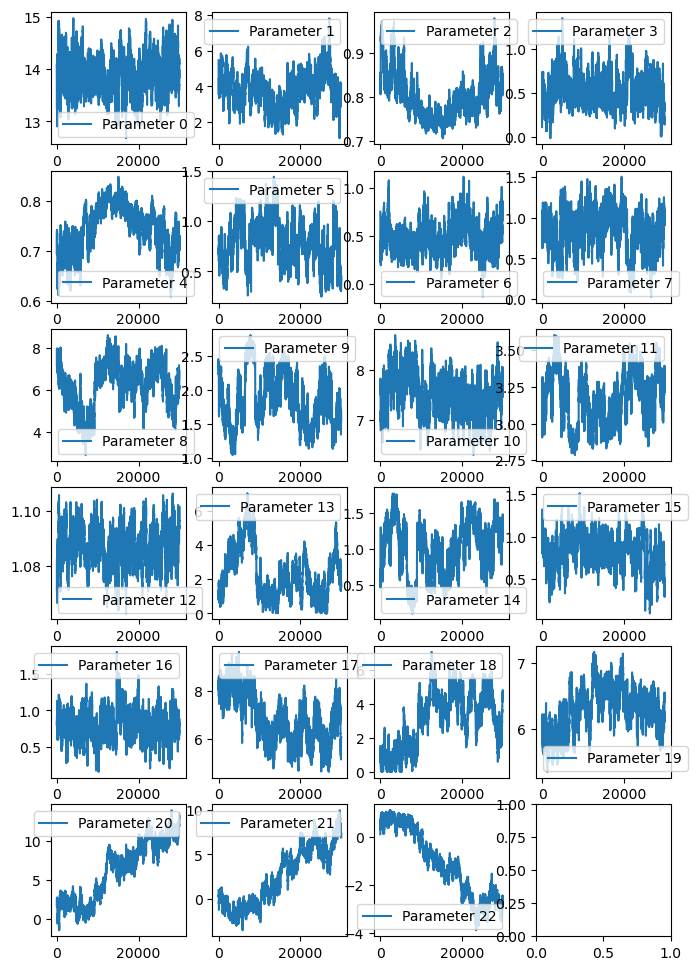

In [117]:
# Trace plots
fig, axs = plt.subplots(6, 4, figsize=(8,12))

for i, ax in enumerate(axs.flat[:23]):

    ax.plot(x[:,i], label=f'Parameter {i}')
    ax.legend()
plt.show()

In [112]:
x0 = x[-1]
x[-1]

array([13.26058542,  5.47045591,  0.84114016,  0.115727  ,  0.73857156,
        0.61243855,  0.75139444,  1.03468406,  7.89372529,  2.24252105,
        7.6157563 ,  3.05225046,  1.07102586,  1.05102409,  0.71310162,
        1.14352681,  0.84976127,  7.81440126,  1.52802926,  5.77306578,
        2.56365652,  1.02641033,  0.10462862])

In [115]:
cov = 0.1*np.cov(x[15000:].T)

In [105]:
cov

array([[ 1.02181786e-01, -2.34794912e-02,  4.60537104e-03,
         7.89157617e-03, -6.83206626e-03,  1.77706975e-02,
        -9.28460974e-03,  7.52913151e-03,  2.70829515e-02,
        -1.25395810e-02, -6.65430733e-03,  4.24963823e-03,
         7.01138171e-04, -1.06000892e-01,  1.10012047e-02,
        -2.45773951e-03,  6.63359811e-03,  5.55372971e-02,
        -3.04905912e-02,  2.91598334e-02, -4.38624294e-02,
         2.75147138e-02, -8.87170822e-04],
       [-2.34794912e-02,  5.49570182e-01,  3.12979230e-02,
         4.60143089e-02, -1.90853832e-02, -1.86384088e-02,
        -6.61854781e-02, -5.26335904e-02,  3.40997075e-01,
         1.92610113e-01,  9.42295906e-02, -7.10356997e-02,
        -1.53427170e-03, -2.21515618e-01, -1.85327827e-01,
         4.46131306e-02,  1.82313637e-02,  5.81580879e-01,
        -6.31092702e-02,  2.01570598e-01, -1.01753134e-01,
        -6.62958613e-02, -1.21869854e-02],
       [ 4.60537104e-03,  3.12979230e-02,  4.35897288e-03,
         6.79123186e-03, -2.6

In [31]:
n = 0
x1 = 2
x2 = 4

(n + 1) / (x2**(n+1) - x1**(n+1)) / (n + 2) * (x2**(n+2) - x1**(n+2))

3.0

In [118]:
def make_dsig_dt_plot(dataset,meson,source,params):

    # print(params)
    print(chi_sq_omega_data(params), chi_sq_phi_data(params), chi_sq_rho_data(params), chi_sq_priors(params), chi_sq_gamma_proton(params), chi_sq_rho_data_e(params))
    
    # Load data
    sel = dataset['source'] == source
    dsig_dt_obs = np.array(dataset['dsigdt (mu barn/GeV^2)'])[sel]
    dsig_dt_err = np.array(dataset['dsigdt error (mu barn/GeV^2)'])[sel]
    dsig_dt_err = np.sqrt(dsig_dt_err**2 + (0.1 * dsig_dt_obs)**2)
    t_abs_obs = np.array(np.abs(dataset['t']))[sel]
    W = np.array(dataset['W'])[sel]

    t = - np.linspace(min(t_abs_obs), max(t_abs_obs), num=50)
    
    try:
        Q2 = np.array(dataset['Q2'])[sel]
        s_tot = np.array(dataset['s_tot'])[sel]

        # Calculate model
        if meson == 'rho':
            dsig_dt_model = dsig_dt_virtual_rho(s_tot,W,Q2,t,params)
        elif meson == 'omega':
            dsig_dt_model = dsig_dt_virtual_omega(s_tot,W,Q2,t,params)
        elif meson == 'phi':
            dsig_dt_model = dsig_dt_virtual_phi(s_tot,W,Q2,t,params)
        else:
            raise Exception('Unknown meson', meson)
            
    except:
        Q2 = 0

        # Check all same W
        if np.all(W == W[0]):
            pass
        else:
            raise Exception('W =', W)
        
        # Calculate model
        if meson == 'rho':
            dsig_dt_model = dsig_dt_rho(W[0],t,params)
        elif meson == 'omega':
            dsig_dt_model = dsig_dt_omega(W[0],t,params)
        elif meson == 'phi':
            dsig_dt_model = dsig_dt_phi(W[0],t,params)
        else:
            raise Exception('Unknown meson', meson)
            
    # Plot data
    plt.errorbar(t_abs_obs, dsig_dt_obs, yerr=dsig_dt_err, fmt='.', capsize=3)
    plt.plot(np.abs(t), dsig_dt_model)
    plt.yscale('log')
    # plt.show()

def make_sig_plot(dataset,meson,source,params):

    # print(params)
    print(chi_sq_omega_data(params), chi_sq_phi_data(params), chi_sq_rho_data(params), chi_sq_priors(params), chi_sq_gamma_proton(params), chi_sq_rho_data_e(params))
    
    # Load data
    sel = dataset['source'] == source
    sig_obs = np.array(dataset['sig (mu barn)'])[sel]
    sig_err = np.array(dataset['sig error (mu barn)'])[sel]
    sig_err = np.sqrt(sig_err**2 + (0.1 * sig_obs)**2)
    W = np.array(dataset['W'])[sel]

    Q2 = np.array(dataset['Q2'])[sel]
    s_tot = np.array(dataset['s_tot'])[sel][0]

    # Calculate model
    if meson == 'rho':
        sig_model_func = sig_virtual_rho
    elif meson == 'omega':
        sig_model_func = sig_virtual_omega
    elif meson == 'phi':
        sig_model_func = sig_virtual_phi
    else:
        raise Exception('Unknown meson', meson)

    fix, axs = plt.subplots(1,2)
    
    # Plot vs Q2
    for Wi in np.unique(W):

        sel_W = W == Wi
        axs[0].errorbar(Q2[sel_W], sig_obs[sel_W], yerr=sig_err[sel_W], fmt='.', capsize=3)
        
        Q2_arr = np.linspace(min(Q2[sel_W]), max(Q2[sel_W]), num=10)
        axs[0].plot(Q2_arr, sig_model_func(s_tot,Wi,Q2_arr,params))

    # Plot vs W
    for Q2i in np.unique(Q2):

        sel_Q2 = Q2 == Q2i
        axs[1].errorbar(W[sel_Q2], sig_obs[sel_Q2], yerr=sig_err[sel_Q2], fmt='.', capsize=3)
        
        W_arr = np.linspace(min(W[sel_Q2]), max(W[sel_Q2]), num=10)
        axs[1].plot(W_arr, sig_model_func(s_tot,W_arr,Q2i,params))
    
    axs[0].set_yscale('log')
    axs[1].set_yscale('log')
        
    # plt.show()



539.1666263334982 474.10211743509603 7.82265022623866 19.05295124969512 394.32336635271633 1922.635006990761
539.2463442864973 474.11471409715955 7.822727379021734 19.0393234990798 394.32336635271633 1922.738178570614


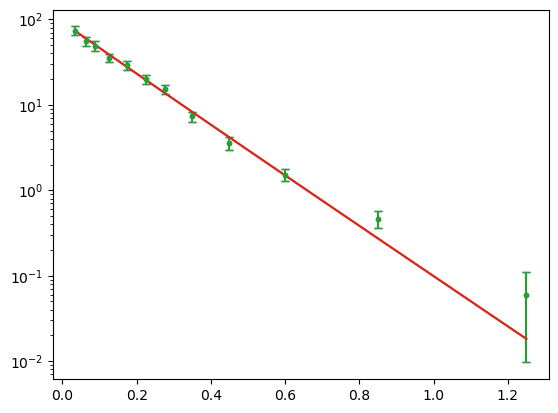

In [119]:
p = np.array(x[-2])
make_dsig_dt_plot(rho_photo_data,'rho','ballam',p)

p[1] = 4
make_dsig_dt_plot(rho_photo_data,'rho','ballam',p)

540.2973610184388 483.91894833786216 4.087427610918508 45.12324073510559 395.06661876495366 1638.4235809664026


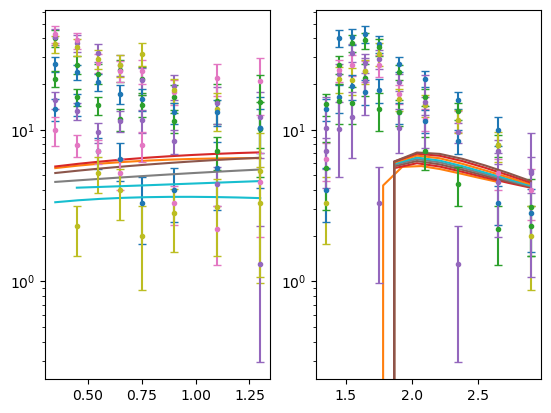

In [94]:
make_sig_plot(rho_electro_data,'rho','Joos',p)

In [95]:
mp**2 + 2 * mp * 7.2

14.391472469267033

In [38]:
rho_photo_data

{'dsigdt (mu barn/GeV^2)': array([7.36250e+01, 5.58000e+01, 4.91500e+01, 3.54750e+01, 2.90750e+01,
        1.98750e+01, 1.52750e+01, 7.30000e+00, 3.60000e+00, 1.52500e+00,
        4.63333e-01, 6.00000e-02]),
 'dsigdt error (mu barn/GeV^2)': array([5.  , 4.1 , 3.4 , 2.2 , 2.  , 1.5 , 1.2 , 0.7 , 0.5 , 0.2 , 0.09,
        0.05]),
 't': array([-0.035 , -0.0625, -0.0875, -0.125 , -0.175 , -0.225 , -0.275 ,
        -0.35  , -0.45  , -0.6   , -0.85  , -1.25  ]),
 'W': array([4.281, 4.281, 4.281, 4.281, 4.281, 4.281, 4.281, 4.281, 4.281,
        4.281, 4.281, 4.281]),
 'source': array(['ballam', 'ballam', 'ballam', 'ballam', 'ballam', 'ballam',
        'ballam', 'ballam', 'ballam', 'ballam', 'ballam', 'ballam'],
       dtype=object)}

In [76]:
rho_electro_data

{'sig (mu barn)': array([13.6, 14.7,  7.2,  6.4,  3.3,  4. ,  5.6, 10.3, 40.3, 26.8, 23.4,
        24.8, 21.7, 16.3, 15.4, 10.1, 40.9, 37.3, 32.1, 26.8, 21.2, 19.4,
        15. , 12.1, 42.6, 38.8, 27.6, 24.4, 24.3, 17.8, 21.8, 21. , 36.8,
        35. , 29.3, 26.6, 31.7, 18.3, 13.7,  3.3, 27.1, 24. , 20.6, 17.2,
        15.9, 13. , 13.1, 10.3, 21.7, 16.3, 14.5, 11.7, 14.5, 11.4,  7.2,
        15.2, 15.7, 13.3,  9.6, 11.4, 11.5,  8.4,  4.4,  1.3,  9.9,  7.9,
         7.2,  5.2,  7.9,  3.3,  2.2,  4.5,  2.3,  5.2,  4. ,  2. ,  2.8,
         3.1,  5.3]),
 'sig error (mu barn)': array([1.8, 1.9, 1.5, 1.7, 1.5, 1.5, 2.6, 6.1, 3. , 2.5, 2.6, 3.3, 3.7,
        3. , 4.3, 5.1, 3. , 2.8, 3. , 3.3, 3.6, 3.1, 3.9, 5.5, 3. , 2.8,
        2.7, 3.1, 3.7, 2.8, 4.6, 8.3, 2.8, 2.7, 2.8, 3.3, 4.3, 2.8, 3.6,
        2.3, 1.6, 1.4, 1.6, 1.8, 2.1, 1.6, 2.2, 3.1, 1.6, 1.3, 1.4, 1.5,
        2. , 1.6, 1.6, 7.5, 1.4, 1. , 1.1, 1.4, 1.7, 1.2, 1.2, 1. , 1.9,
        1. , 1.1, 1.1, 1.6, 0.9, 0.9, 2.5, 0.8, 1.3, 1.